# Entity Risk Scoring — End-to-End Demo

This notebook demonstrates the full pipeline on a single Bitcoin UTXO subgraph:

1. Load a subgraph from the Elliptic2 test set
2. Score it with the calibrated SAGE+Edge model → continuous risk score 0–100
3. Run an adversarial topology rewiring attack (hub-based mixer simulation)
4. Re-score the attacked subgraph and compare
5. Compute feature importance via Integrated Gradients
6. Export to `GNNInferenceOutput` — the stable JSON interface for downstream systems

In [10]:
%matplotlib inline
import os, sys

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.exists(os.path.join(REPO_ROOT, 'config.yaml')):
    REPO_ROOT = os.getcwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import torch
import yaml

from src.dataset.Elliptic2Dataset import Elliptic2Dataset
from src.models.risk_scorer import SubgraphRiskScorer
from src.inference.export import run_inference
from src.attacks.topology_rewiring import TopologyRewiringAttack, TopologyAnalyzer
from src.attacks.node_injection import LicitDistribution

with open('config.yaml') as f:
    config = yaml.safe_load(f)

print(f'Working dir: {os.getcwd()}')
print('Imports OK')

Working dir: /home/joachim/Desktop/Master-Thesis
Imports OK


## 1. Load Test Subgraphs

In [11]:
ds_test  = Elliptic2Dataset(processed_dir=config['data']['processed_dir'], split='test')
ds_train = Elliptic2Dataset(processed_dir=config['data']['processed_dir'], split='train')

suspicious = [d for d in ds_test if int(d.y.item()) == 1]
licit      = [d for d in ds_test if int(d.y.item()) == 0]

print(f'Test set: {len(ds_test)} subgraphs | {len(suspicious)} suspicious | {len(licit)} licit')

demo = sorted(suspicious, key=lambda d: d.num_nodes)[len(suspicious) // 2]
print(f'Demo subgraph: {demo.num_nodes} nodes, {demo.edge_index.shape[1]} edges, label={int(demo.y.item())}')

  [TEST] 12181 subgraphs (class 0: 11905, class 1: 276)
  [TRAIN] 91357 subgraphs (class 0: 89285, class 1: 2072)
Test set: 12181 subgraphs | 276 suspicious | 11905 licit
Demo subgraph: 7 nodes, 8 edges, label=1


## 2. Risk Score — Clean Subgraph

In [12]:
scorer = SubgraphRiskScorer.best_model(
    config_path='config.yaml',
    results_path='data/results/full_results.json',
    checkpoint_dir='checkpoints',
)

risk_clean = scorer.score(demo)

tier_colors = {'LOW': '#2ecc71', 'MEDIUM': '#f39c12', 'HIGH': '#e67e22', 'CRITICAL': '#e74c3c'}

print('=== Clean subgraph ===')
print(f'  Risk score : {risk_clean.risk_score}/100')
print(f'  Tier       : {risk_clean.tier}')
print(f'  P(illicit) : {risk_clean.prob_illicit:.4f}')
print(f'  Percentile : {risk_clean.percentile:.1%}  (higher than {risk_clean.percentile:.1%} of test set)')
print(f'  Prediction : {"SUSPICIOUS" if risk_clean.prediction == 1 else "LICIT"} (threshold={risk_clean.threshold})')

=== Clean subgraph ===
  Risk score : 98/100
  Tier       : CRITICAL
  P(illicit) : 0.9785
  Percentile : 98.6%  (higher than 98.6% of test set)
  Prediction : SUSPICIOUS (threshold=0.04)


## 3. Visualise Subgraph

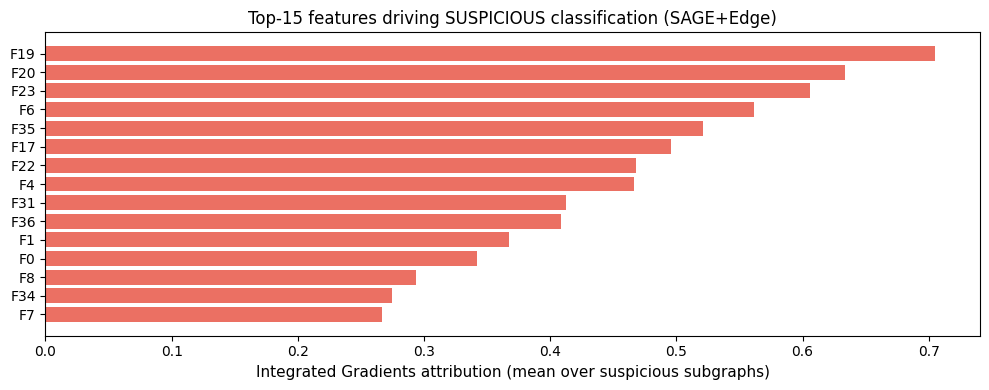

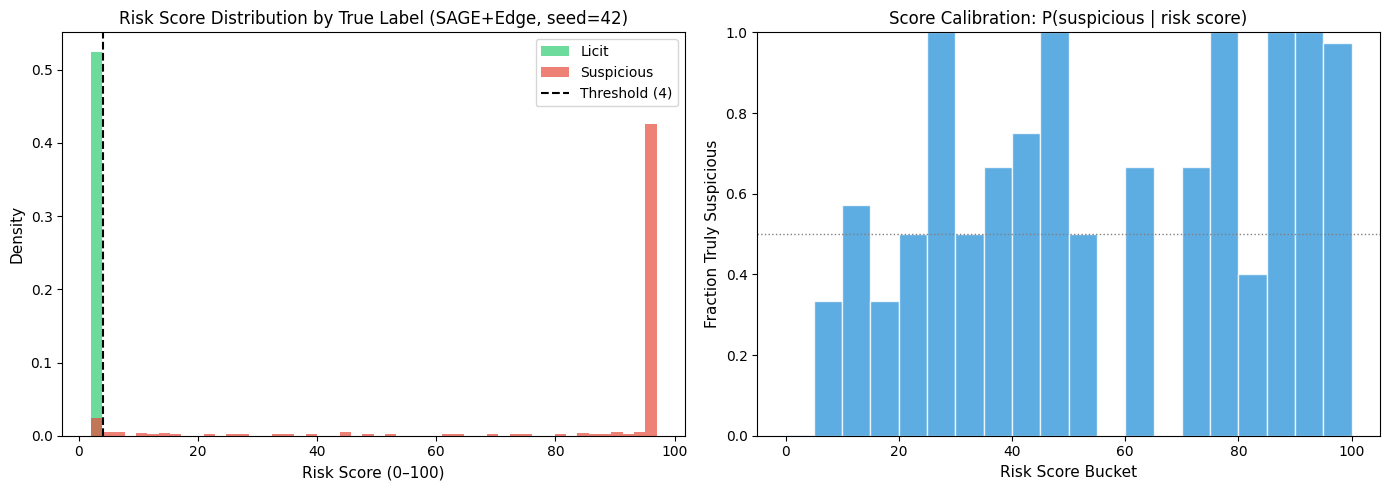

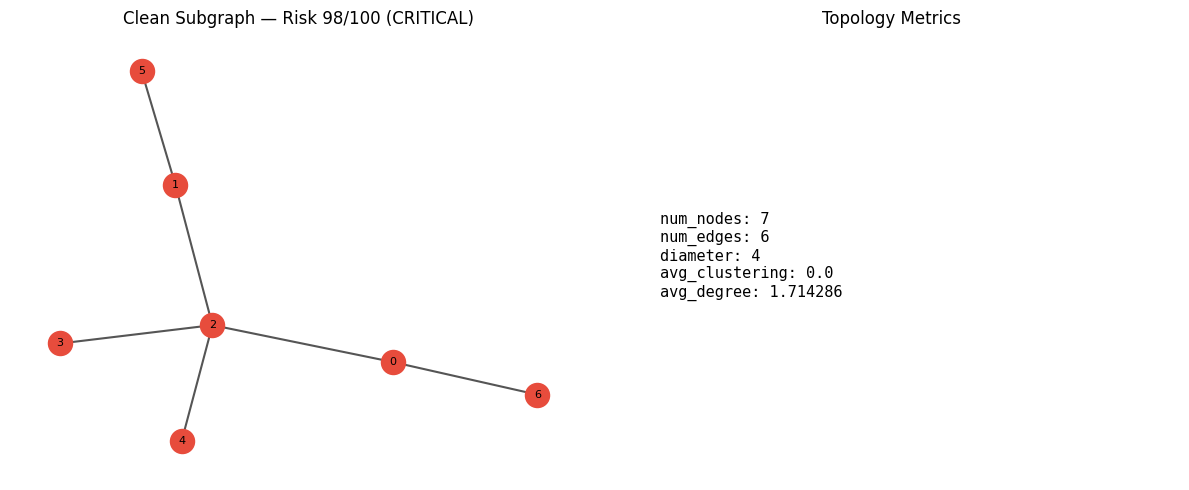

In [13]:
def pyg_to_nx(data):
    G = nx.Graph()
    G.add_nodes_from(range(data.num_nodes))
    ei = data.edge_index.cpu().numpy()
    for u, v in zip(ei[0].tolist(), ei[1].tolist()):
        if u != v:
            G.add_edge(u, v)
    return G

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
G = pyg_to_nx(demo)
pos = nx.spring_layout(G, seed=42)
color = tier_colors[risk_clean.tier]

nx.draw(G, pos, ax=axes[0], node_color=color, node_size=300,
        edge_color='#555', width=1.5, with_labels=True, font_size=8)
axes[0].set_title(f'Clean Subgraph — Risk {risk_clean.risk_score}/100 ({risk_clean.tier})', fontsize=12)

topo = TopologyAnalyzer.compute_metrics(demo)
info = '\n'.join([f'{k}: {v}' for k, v in topo.items()])
axes[1].text(0.1, 0.5, info, transform=axes[1].transAxes,
             fontsize=11, verticalalignment='center', family='monospace')
axes[1].set_title('Topology Metrics', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. Adversarial Attack — Star Topology (Hub-Based Mixer Simulation)

The `star` rewiring injects a hub node connected to high-degree addresses, simulating a centralized mixer / exchange hub pattern (hub-and-spoke topology, analogous to a custodial tumbler or Uniswap-style AMM).
This is the most efficient attack: 7× lower cost-per-ASR than chain-based methods.

In [14]:
licit_dist = LicitDistribution(ds_train)
attack     = TopologyRewiringAttack(licit_dist, technique='star', k_intermediates=3)
demo_attacked = attack.attack(demo)

risk_attacked = scorer.score(demo_attacked)

print('=== After star rewiring (hub-based mixer simulation) ===')
print(f'  Risk score : {risk_attacked.risk_score}/100  (was {risk_clean.risk_score})')
print(f'  Tier       : {risk_attacked.tier}  (was {risk_clean.tier})')
print(f'  P(illicit) : {risk_attacked.prob_illicit:.4f}  (was {risk_clean.prob_illicit:.4f})')
print(f'  Prediction : {"SUSPICIOUS" if risk_attacked.prediction == 1 else "LICIT"}  (was {"SUSPICIOUS" if risk_clean.prediction == 1 else "LICIT"})')

delta = risk_attacked.risk_score - risk_clean.risk_score
direction = '↑' if delta > 0 else ('↓' if delta < 0 else '→')
print(f'  Score delta: {direction} {abs(delta)} points')

  LicitDistribution: 815,449 licit nodes | 1,686,698 licit edges | node_dim=43 edge_dim=95
=== After star rewiring (hub-based mixer simulation) ===
  Risk score : 98/100  (was 98)
  Tier       : CRITICAL  (was CRITICAL)
  P(illicit) : 0.9785  (was 0.9785)
  Prediction : SUSPICIOUS  (was SUSPICIOUS)
  Score delta: → 0 points


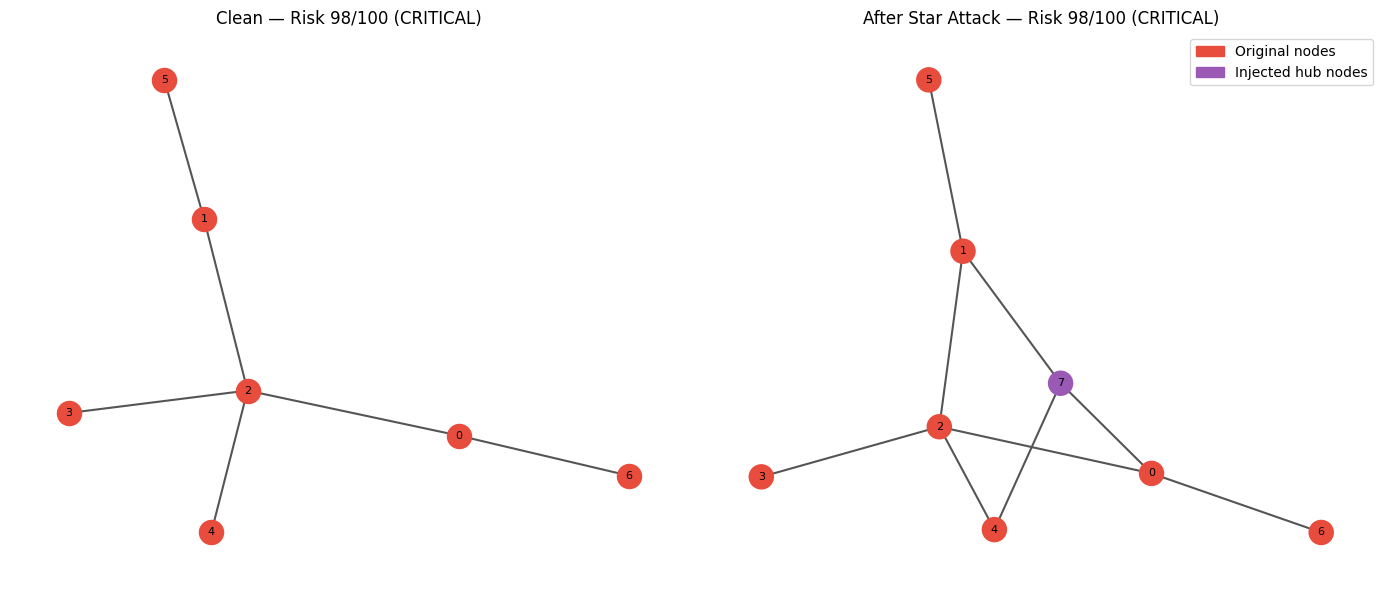

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

G_clean    = pyg_to_nx(demo)
G_attacked = pyg_to_nx(demo_attacked)

n_orig = demo.num_nodes
orig_nodes     = list(range(n_orig))
injected_nodes = [n for n in G_attacked.nodes() if n >= n_orig]

pos_clean    = nx.spring_layout(G_clean,    seed=42)
pos_attacked = nx.spring_layout(G_attacked, seed=42)

nx.draw(G_clean, pos_clean, ax=axes[0],
        node_color=tier_colors[risk_clean.tier], node_size=300,
        edge_color='#555', width=1.5, with_labels=True, font_size=8)
axes[0].set_title(f'Clean — Risk {risk_clean.risk_score}/100 ({risk_clean.tier})', fontsize=12)

node_colors_attacked = [
    tier_colors[risk_attacked.tier] if n in orig_nodes else '#9b59b6'
    for n in G_attacked.nodes()
]
nx.draw(G_attacked, pos_attacked, ax=axes[1],
        node_color=node_colors_attacked, node_size=300,
        edge_color='#555', width=1.5, with_labels=True, font_size=8)
axes[1].set_title(f'After Star Attack — Risk {risk_attacked.risk_score}/100 ({risk_attacked.tier})', fontsize=12)

patch_orig     = mpatches.Patch(color=tier_colors[risk_attacked.tier], label='Original nodes')
patch_injected = mpatches.Patch(color='#9b59b6', label='Injected hub nodes')
axes[1].legend(handles=[patch_orig, patch_injected], loc='upper right')

plt.tight_layout()
plt.show()

## 5. Feature Importance via Integrated Gradients

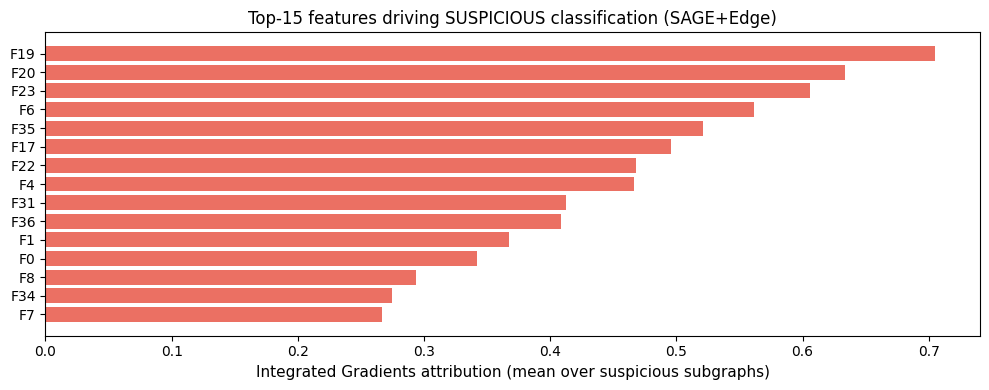

Top-5 feature indices by IG attribution:
  #1: F19  IG=0.7053
  #2: F20  IG=0.6333
  #3: F23  IG=0.6062
  #4: F6  IG=0.5611
  #5: F35  IG=0.5207


In [16]:
from src.analysis.feature_importance import FeatureImportanceAnalyzer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scorer.model.to(device)

analyzer = FeatureImportanceAnalyzer(scorer.model, suspicious[:50], device)
ig_scores = analyzer.integrated_gradients(n_steps=50, max_samples=50)

top_k = 15
top_idx   = np.argsort(ig_scores)[::-1][:top_k]
top_scores = ig_scores[top_idx]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh([f'F{i}' for i in top_idx], top_scores, color='#e74c3c', alpha=0.8)
ax.set_xlabel('Integrated Gradients attribution (mean over suspicious subgraphs)', fontsize=11)
ax.set_title(f'Top-{top_k} features driving SUSPICIOUS classification (SAGE+Edge)', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top-5 feature indices by IG attribution:')
for rank, (idx, score) in enumerate(zip(top_idx[:5], top_scores[:5]), 1):
    print(f'  #{rank}: F{idx}  IG={score:.4f}')

## 6. GNNInferenceOutput — Stable JSON Contract

This is the output format consumed by the RAG-based AML assistant and cross-chain risk scoring layer.

In [17]:
output = run_inference(
    demo,
    conv_type='sage_edge',
    seed=42,
    subgraph_id='demo_suspicious_001',
    compute_ig=True,
    ig_steps=50,
    config_path='config.yaml',
    results_path='data/results/full_results.json',
    checkpoint_dir='checkpoints',
)

d = output.to_dict()
d['subgraph_edges'] = f'[{len(d["subgraph_edges"])} edges — truncated]'
d['ig_scores']      = f'[{len(output.ig_scores)} values — first 5: {[round(x,4) for x in output.ig_scores[:5]]}]'
print(json.dumps(d, indent=2))

{
  "subgraph_id": "demo_suspicious_001",
  "conv_type": "sage_edge",
  "seed": 42,
  "class_prob_illicit": 0.9785031676292419,
  "risk_score": 98,
  "percentile": 0.9862901239635498,
  "tier": "CRITICAL",
  "prediction": 1,
  "threshold": 0.04,
  "ig_scores": "[43 values \u2014 first 5: [0.0027, 0.0035, 0.0022, 0.004, 0.0068]]",
  "topology_metrics": {
    "num_nodes": 7,
    "num_edges": 6,
    "diameter": 4,
    "avg_clustering": 0.0,
    "avg_degree": 1.714286
  },
  "subgraph_edges": "[8 edges \u2014 truncated]"
}


## 7. Score Distribution — Test Set

Risk score distribution over the full test set, stratified by true label.

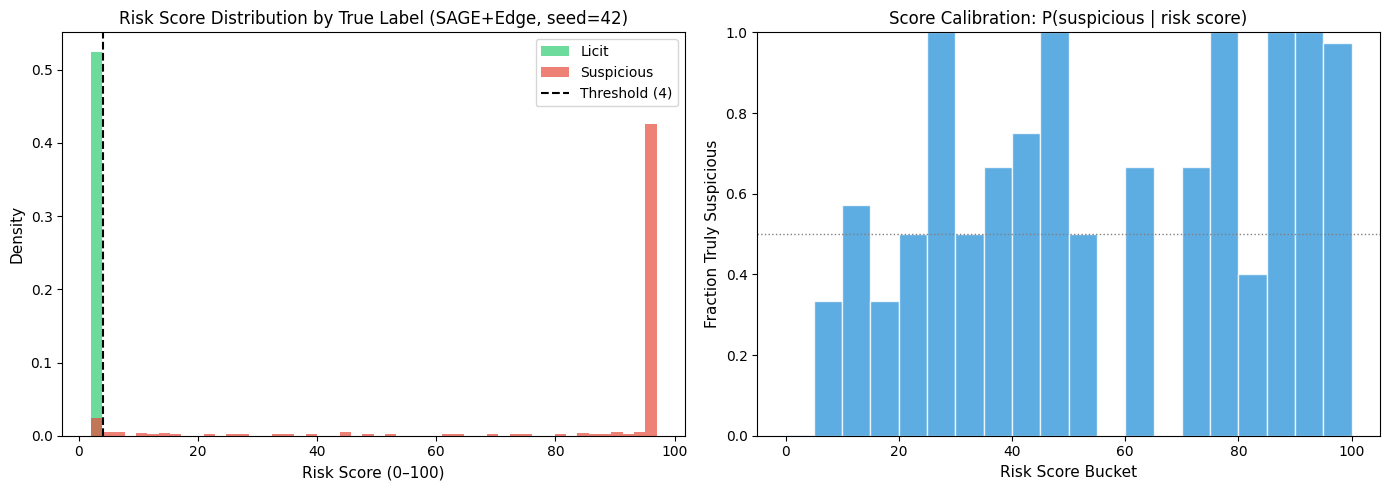

Test set: 276 suspicious (2.27%) | 11905 licit
High-risk (score ≥ 75): precision = 96.3% truly suspicious


In [18]:
with open('data/results/full_results.json') as f:
    full_results = json.load(f)

r = next(x for x in full_results if x['conv_type'] == 'sage_edge' and x['seed'] == 42)

probs  = np.array(r['test_probs'])
labels = np.array(r['test_labels'])
scores = (probs * 100).astype(int).clip(0, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, name, color in [(0, 'Licit', '#2ecc71'), (1, 'Suspicious', '#e74c3c')]:
    mask = labels == label
    axes[0].hist(scores[mask], bins=50, alpha=0.7, color=color, label=name, density=True)

axes[0].axvline(r['threshold'] * 100, color='black', linestyle='--', linewidth=1.5,
                label=f'Threshold ({r["threshold"]*100:.0f})')
axes[0].set_xlabel('Risk Score (0–100)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Risk Score Distribution by True Label (SAGE+Edge, seed=42)', fontsize=12)
axes[0].legend(fontsize=10)

buckets = np.arange(0, 101, 5)
precision = []
for lo, hi in zip(buckets[:-1], buckets[1:]):
    mask = (scores >= lo) & (scores < hi)
    precision.append(labels[mask].mean() if mask.sum() > 0 else np.nan)

axes[1].bar(buckets[:-1], precision, width=5, align='edge', color='#3498db', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Risk Score Bucket', fontsize=11)
axes[1].set_ylabel('Fraction Truly Suspicious', fontsize=11)
axes[1].set_title('Score Calibration: P(suspicious | risk score)', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].axhline(0.5, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
plt.show()

print(f'Test set: {(labels==1).sum()} suspicious ({(labels==1).mean():.2%}) | {(labels==0).sum()} licit')
print(f'High-risk (score ≥ 75): precision = {labels[scores >= 75].mean():.1%} truly suspicious')